# ARC-AGI × GEPA: a 12-line agent, evolved into an 89.5% solver

**No human in the loop.** GEPA's reflection LM rewrote the agent.

| | Seed | GEPA-evolved |
|---|---|---|
| Lines of code | 12 | 170 |
| ARC-AGI accuracy (paper, full eval split) | **32.5%** | **89.5%** |
| Cost / task | — | **\$0.14** (Gemini 3 Flash via OpenRouter) |

## How to read this notebook

- **Reviewer mode (default).** No API key, no network. Everything backed by `artifacts/`. Runs top-to-bottom in <60 s.
- **Booth mode** (`DEMO = True` in the CONFIG cell + `OPENROUTER_API_KEY`). Cell 6 runs the evolved agent live on one puzzle (~20 s, ~\$0.005).
- **Re-optimization is *not* run here.** The `optimize_anything` call is shown as code (§1). The full optimization is a multi-hour, multi-dollar job — see `examples/arc_agi/main.py` to reproduce.

Links: [paper](https://arxiv.org/abs/2507.19457) · [GEPA repo](https://github.com/gepa-ai/gepa)

## CONFIG

*This cell exists only for this notebook — mode toggle, paths, and plotting helpers. It is **not** part of the `optimize_anything` API; a real optimization script needs none of this.*

In [1]:
from pathlib import Path
import json

DEMO = False  # set True + export OPENROUTER_API_KEY to enable §6's live run
ROOT = Path('.')
ARTIFACTS = ROOT / 'artifacts'
# MODEL_ID is only used in booth mode (§6 with DEMO=True). Reviewer mode never hits the network.

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display

# ARC color palette (standard)
ARC_PALETTE = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25',
]
ARC_CMAP = plt.matplotlib.colors.ListedColormap(ARC_PALETTE)
ARC_NORM = plt.matplotlib.colors.BoundaryNorm(boundaries=range(11), ncolors=10)

def draw_grid(ax, grid, title=''):
    if grid is None:
        ax.imshow(np.full((1, 1), 0.5), cmap='Greys', vmin=0, vmax=1)
        ax.text(0, 0, '(no parseable\noutput)', ha='center', va='center',
                color='#888', fontsize=8, fontstyle='italic')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#888'); spine.set_linewidth(0.6); spine.set_linestyle('--')
        if title:
            ax.set_title(title, fontsize=9)
        return
    g = np.asarray(grid)
    ax.imshow(g, cmap=ARC_CMAP, norm=ARC_NORM)
    # ARC-style cell borders: thin white grid between pixels
    ax.set_xticks(np.arange(-0.5, g.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, g.shape[0], 1), minor=True)
    ax.grid(which='minor', color='#FFFFFF', linewidth=0.4)
    ax.tick_params(which='minor', length=0)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444'); spine.set_linewidth(0.6)
    if title:
        ax.set_title(title, fontsize=9)

## 1 · The API

GEPA's `optimize_anything` takes a text artifact (here: agent source code) and a scoring function. The reflection LM proposes mutations; the engine keeps a Pareto frontier of candidates by validation score.

```python
from gepa.optimize_anything import optimize_anything, GEPAConfig

result = optimize_anything(
    seed_candidate=SEED_AGENT_CODE,        # str — the artifact to optimize
    evaluator=evaluate,                    # (candidate, example) -> (score, SideInfo)
    dataset=train_set,
    valset=val_set,
    objective=OBJECTIVE,                   # str — natural-language goal
    background=BACKGROUND,                 # str — task description for the reflection LM
    config=GEPAConfig(...),
)
```

That's the whole interface. The `evaluator` returns a score plus a `SideInfo` dict — diagnostics the reflection LM reads when proposing the next mutation. We'll look at one real `SideInfo` payload in §4.

## 2 · The running example

One ARC puzzle from the validation split. We'll keep using this puzzle throughout — first to show the seed failing on it, then to show the evolved agent solving it.

Puzzle ID: bda2d7a6
  3 training pairs, 2 test input(s)


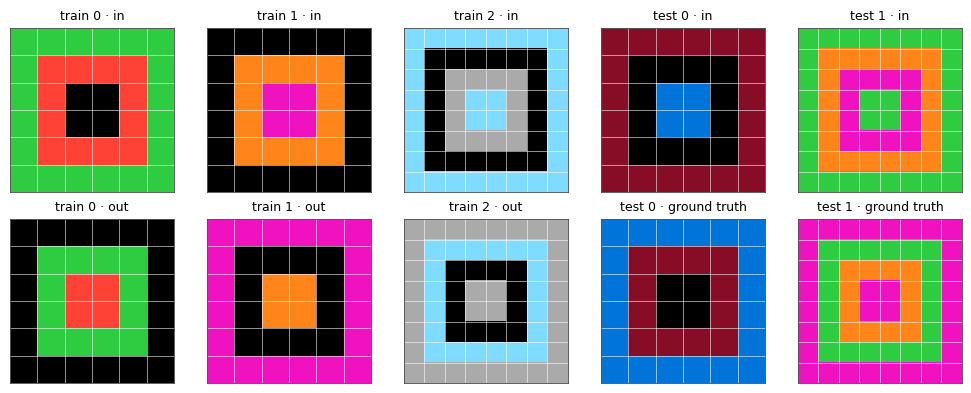

In [2]:
EXAMPLE = json.loads((ARTIFACTS / 'example_puzzle.json').read_text())
puzzle = EXAMPLE['puzzle']
print(f"Puzzle ID: {EXAMPLE['problem_id']}")
print(f"  {len(puzzle['train_inputs'])} training pairs, {len(puzzle['test_inputs'])} test input(s)")

n_train = len(puzzle['train_inputs'])
n_test = len(puzzle['test_inputs'])
fig, axes = plt.subplots(2, n_train + n_test, figsize=(2 * (n_train + n_test), 4))
for i, (gi, go) in enumerate(zip(puzzle['train_inputs'], puzzle['train_outputs'])):
    draw_grid(axes[0, i], gi, f'train {i} · in')
    draw_grid(axes[1, i], go, f'train {i} · out')
for j, (ti, to) in enumerate(zip(puzzle['test_inputs'], puzzle['test_outputs'])):
    col = n_train + j
    draw_grid(axes[0, col], ti, f'test {j} · in')
    draw_grid(axes[1, col], to, f'test {j} · ground truth')
plt.tight_layout(); plt.show()

## 3 · The seed (12 lines)

One LLM call, predict every input grid in one shot, regex-parse the response. This is the artifact GEPA started from.

In [3]:
print(EXAMPLE['seed']['agent_code'])


import json, re

def solve(train_inputs, train_outputs, test_inputs, llm):
    training_examples = "\n".join(f"Input: {i}\nOutput: {o}" for i, o in zip(train_inputs, train_outputs))
    problem_inputs = "\n".join(f"Input {i}: {x}" for i, x in enumerate(train_inputs + test_inputs))

    prompt = f"ARC puzzle. Training examples:\n{training_examples}\n\nPredict output for EACH input as JSON [[...]]:\n{problem_inputs}"
    response = llm(prompt)

    grids = [json.loads(g) for g in re.findall(r"\[\[.*?\]\]", response.replace("\n", ""))]
    n_train = len(train_inputs)
    return {
        "train": grids[:n_train],
        "test": [[g] for g in grids[n_train:]]
    }



**Seed's cached prediction on the puzzle above (test 0):**

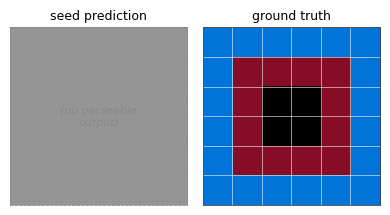

Seed test score: 0%  ·  1 LLM call


In [4]:
seed_test_pred = EXAMPLE['seed']['predictions_test'][0]
fig, axes = plt.subplots(1, 2, figsize=(4, 2.2))
draw_grid(axes[0], seed_test_pred, 'seed prediction')
draw_grid(axes[1], puzzle['test_outputs'][0], 'ground truth')
plt.tight_layout(); plt.show()
print(f"Seed test score: {EXAMPLE['seed']['test_score']:.0%}  ·  {EXAMPLE['seed']['llm_calls']} LLM call")

## 4 · The evaluator and what GEPA's reflection LM sees

The optimizer never inspects the agent code itself. It only sees what `evaluator` returns: a scalar score, plus a `SideInfo` dict the reflection LM reads as evidence for the next mutation.

Condensed evaluator (full version: `gepa/examples/arc_agi/utils.py`):

```python
def evaluate(candidate: str, example: dict) -> tuple[float, SideInfo]:
    result = run_agent(
        agent_code=candidate,
        train_in=example['train_inputs'], train_out=example['train_outputs'],
        test_in=example['test_inputs'],   test_out=example['test_outputs'],
        model_id=MODEL_ID, max_llm_calls=10,
    )
    score = result['training_score']
    side_info = {
        'problem_id':     example['problem_id'],
        'training_score': result['training_score'],
        'test_score':     result['test_score'],
        'error':          result['error'],
        'train_examples': result['train_examples'],   # input/gold/prediction/feedback per pair
        'trajectory':     result['llms'].get_traces(),  # prompts + responses
    }
    return score, side_info
```

Below is the **real** `SideInfo` payload from the seed's run on our puzzle — the dict GEPA's reflection LM read when proposing the next mutation.

In [5]:
seed = EXAMPLE['seed']
side_info = {
    'problem_id':     EXAMPLE['problem_id'],
    'training_score': seed['training_score'],
    'test_score':     seed['test_score'],
    'error':          None,
    'train_examples': seed['train_examples_detail'],   # input/gold/prediction/correct/feedback per pair
    'trajectory':     {'llm_calls': seed['llm_calls'], 'total_cost': seed['total_cost']},
}

# Top-level shape
for k, v in side_info.items():
    if k == 'train_examples':
        print(f'  {k:18s}  list[{len(v)}]')
    else:
        print(f'  {k:18s}  {v}')

# Drill into one element — this is the per-example diagnostic the reflection LM mutates against
ex0 = side_info['train_examples'][0]
print()
print('train_examples[0]:')
for k in ('correct', 'feedback'):
    val = ex0[k]
    if isinstance(val, str) and len(val) > 120:
        val = val[:120] + '...'
    print(f'  {k:12s}  {val!r}')
print(f"  input shape  ({len(ex0['input'])}, {len(ex0['input'][0])})")
print(f"  gold shape   ({len(ex0['gold'])}, {len(ex0['gold'][0])})")

  problem_id          bda2d7a6
  training_score      0.0
  test_score          0.0
  error               None
  train_examples      list[3]
  trajectory          {'llm_calls': 1, 'total_cost': 0.050556500000000004}

train_examples[0]:
  correct       False
  feedback      'No prediction'
  input shape  (6, 6)
  gold shape   (6, 6)


## 5 · What GEPA discovered

After ~30 accepted mutations the engine settled on a four-stage code-synthesis pipeline:

1. **Programmer** — write a `transform(grid)` numpy function from the training pairs.
2. **Validator** — run the function against every training pair.
3. **Fixer** — on failure, feed the error back to the LM and retry (≤ 2×).
4. **Fallback** — if code never validates, ask the LM to predict the test grid directly.

Two attempts are submitted per test input (best code + fallback) — using ARC-AGI's full attempt budget.

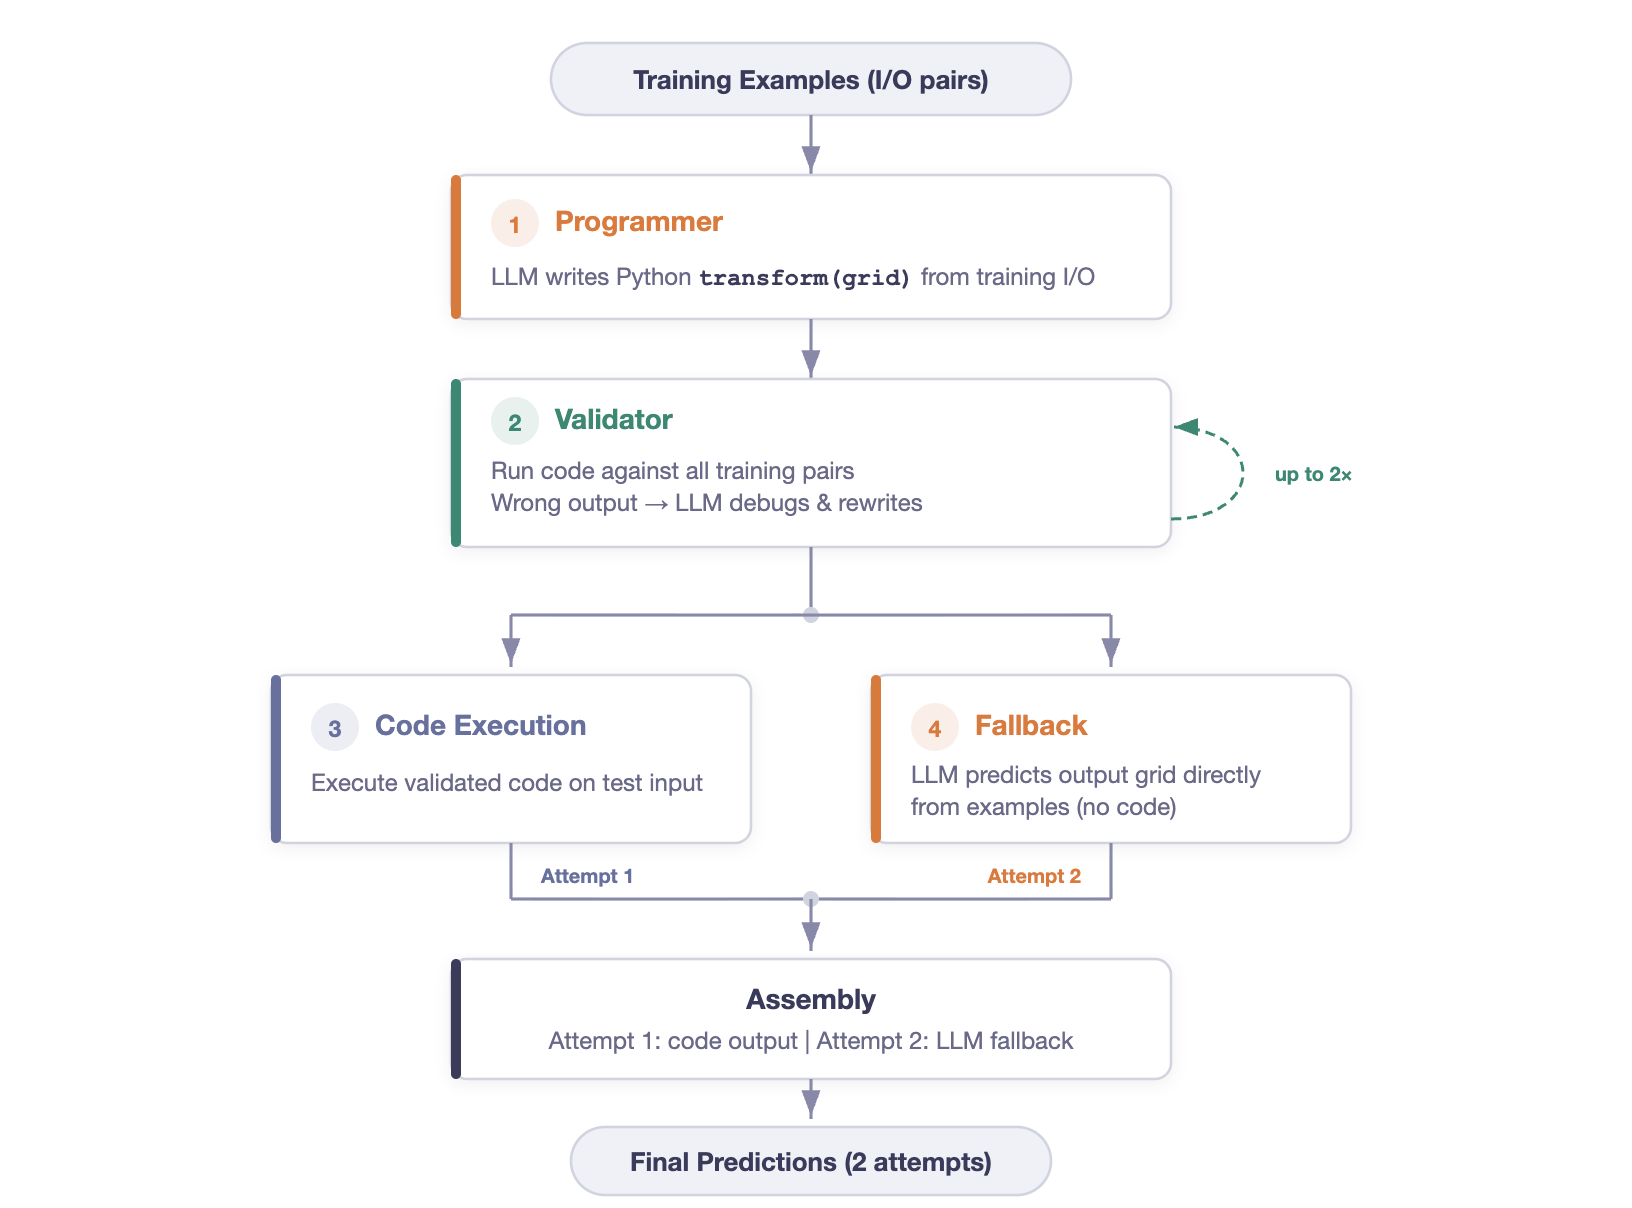

In [6]:
from IPython.display import Image
display(Image(filename='figures/best_agent_architecture.png', width=816))

**Evolved agent's source** — first 35 lines below; full file: [`best_agent.py`](./best_agent.py).

In [7]:
best_code = (ROOT / 'best_agent.py').read_text()
lines = best_code.splitlines()
print('\n'.join(lines[:35]))
print(f'... [{len(lines) - 35} more lines — see best_agent.py]')

import json
import re
import numpy as np

def solve(train_inputs, train_outputs, test_inputs, llm):
    """
    ARC-AGI solver using a multi-stage reasoning and execution pipeline:
    1. Analyst: Infers transformation logic and describes it.
    2. Developer: Writes a Python function to implement the logic.
    3. Validator: Tests the code against ALL training examples and iterates if it fails.
    4. Optimizer: Uses the best-performing code or falls back to direct prediction via LLM.
    """

    def format_grid(grid):
        return json.dumps(grid)

    training_exs = ""
    for idx, (i, o) in enumerate(zip(train_inputs, train_outputs)):
        training_exs += f"Example {idx}:\nInput: {format_grid(i)}\nOutput: {format_grid(o)}\n\n"

    # Stage 1: Initial Programming Attempt
    programmer_prompt = f"""You are an absolute expert programmer and ARC-AGI solver.
Analyze these training examples and identify the transformation rule.
Consider: object properties (color, shape, position),

## 6 · Same puzzle, evolved agent

Reviewer mode: cached prediction from a prior run. Booth mode (`DEMO=True`): live execution against `MODEL_ID` — ~4 LLM calls, ~\$0.005, ~20 s.

*The booth-mode runtime (`run_agent`, `TrackedLLM`) is vendored locally in `arc_runtime.py` so the notebook has no `gepa` source-checkout dependency. `pip install gepa` would also work — see `gepa/examples/arc_agi/utils.py`.*

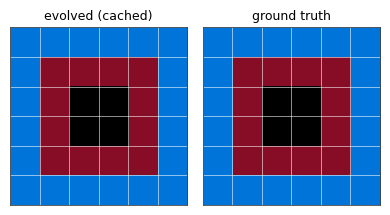

  training: 100%   test: 100%   4 LLM calls   $0.0000


In [8]:
if DEMO:
    from arc_runtime import run_agent   # vendored locally — no gepa-checkout dependency
    MODEL_ID = 'openrouter/google/gemini-3-flash-preview'
    print('Running evolved agent live...')
    live = run_agent(
        agent_code=(ROOT / 'best_agent.py').read_text(),
        train_in=puzzle['train_inputs'], train_out=puzzle['train_outputs'],
        test_in=puzzle['test_inputs'],   test_out=puzzle['test_outputs'],
        model_id=MODEL_ID, max_llm_calls=10,
    )
    evolved_test_pred = live['test_examples'][0]['prediction']
    train_score, test_score = live['training_score'], live['test_score']
    cost = live['llms'].total_cost; calls = len(live['llms'].calls)
    label = 'evolved (live)'
else:
    evolved_test_pred = EXAMPLE['evolved']['predictions_test'][0][0]
    train_score = EXAMPLE['evolved']['training_score']
    test_score  = EXAMPLE['evolved']['test_score']
    cost = EXAMPLE['evolved']['total_cost']; calls = EXAMPLE['evolved']['llm_calls']
    label = 'evolved (cached)'

fig, axes = plt.subplots(1, 2, figsize=(4, 2.2))
draw_grid(axes[0], evolved_test_pred, label)
draw_grid(axes[1], puzzle['test_outputs'][0], 'ground truth')
plt.tight_layout(); plt.show()
print(f'  training: {train_score:.0%}   test: {test_score:.0%}   {calls} LLM calls   ${cost:.4f}')

## 7 · Search trajectory

Validation accuracy of every accepted candidate vs. metric-call budget. The seed enters at zero; the best candidate (`best_agent.py`, the one shown in §5) is found at **1114 metric calls — well inside a 1500-call budget**, even though the actual run continued past 2000 calls. We display the truncated 1500-call view here to show what an early-stopping policy would have shipped.

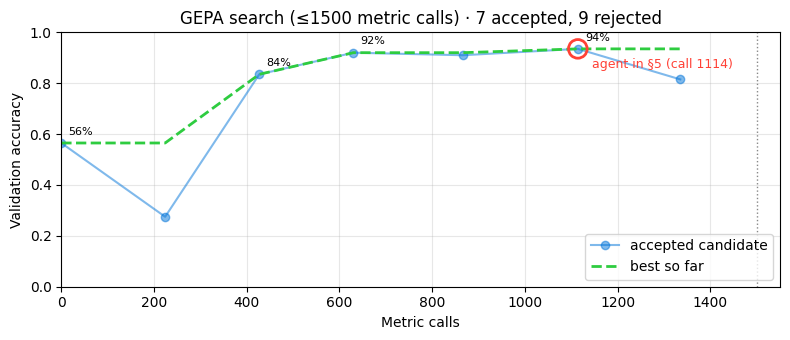

Best agent: 93.5% at metric call 1114.


In [9]:
BUDGET = 1500   # metric-call cap for the displayed trajectory

acc = json.loads((ARTIFACTS / 'accepted_candidates.json').read_text())
ac = json.loads((ARTIFACTS / 'all_candidates.json').read_text())

# Truncate at BUDGET (best agent at mc=1114 is captured)
in_budget = [a for a in acc if a['metric_calls_by_discovery'] <= BUDGET]
mcs    = [a['metric_calls_by_discovery'] for a in in_budget]
scores = [a['score'] for a in in_budget]
best_so_far = np.maximum.accumulate(scores)
best_idx = int(np.argmax(scores))
best_mc, best_score = mcs[best_idx], scores[best_idx]

# Map iteration → in-budget rejection count (last accepted within budget anchors the cutoff)
last_accepted_iter = max((r['iteration'] for r in ac
                          if r['event_type'] == 'accepted' and r['score'] is not None
                          and r['score'] in scores), default=0)
rejected_in_budget = [r for r in ac if r['event_type'] == 'rejected' and r['iteration'] <= last_accepted_iter]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(mcs, scores, 'o-', color='#0074D9', alpha=0.5, label='accepted candidate')
ax.plot(mcs, best_so_far, '--', color='#2ECC40', linewidth=2, label='best so far')
for a in in_budget:
    if a['is_best_breaking']:
        ax.annotate(f"{a['score']:.0%}", (a['metric_calls_by_discovery'], a['score']),
                    textcoords='offset points', xytext=(5, 6), fontsize=8)
# Highlight the agent shown in §5
ax.scatter([best_mc], [best_score], s=180, facecolors='none', edgecolors='#FF4136', linewidth=2, zorder=5)
ax.annotate(f'agent in §5 (call {best_mc})', (best_mc, best_score),
            textcoords='offset points', xytext=(10, -14), fontsize=9, color='#FF4136')
ax.axvline(BUDGET, color='#888', linestyle=':', linewidth=1)
ax.set_xlabel('Metric calls'); ax.set_ylabel('Validation accuracy')
ax.set_ylim(0, 1.0); ax.set_xlim(0, BUDGET + 50); ax.grid(alpha=0.3); ax.legend(loc='lower right')
ax.set_title(f'GEPA search (≤{BUDGET} metric calls) · {len(in_budget)} accepted, {len(rejected_in_budget)} rejected')
plt.tight_layout(); plt.show()

print(f'Best agent: {best_score:.1%} at metric call {best_mc}.')

## 8 · What GEPA tried that *didn't* work

Inside the displayed 1500-call budget the engine rejected several mutations before they reached the validation set. Each candidate is first tested on a 3-puzzle subsample drawn from the parent's evaluation history; if the proposal ties or regresses, it's discarded. The success curve in §7 hides that churn. Concrete examples:

In [10]:
regressions = []
for r in rejected_in_budget:
    n = len(r.get('subsample_ids') or [])
    p = r.get('subsample_score_sum'); q = r.get('new_subsample_score_sum')
    if n and p is not None and q is not None and q < p:
        regressions.append((r['iteration'], r['selected_program_score_percent'], int(p), int(q), n))

print(f'{"iter":>4}  {"parent (full val)":>18}  {"subsample":>14}  verdict')
print('-' * 60)
for it, pct, p, q, n in regressions[:5]:
    print(f'{it:>4}  {pct:>16.1f}%  parent {p}/{n} → proposed {q}/{n}  rejected')
extra = max(len(regressions) - 5, 0)
ties = len(rejected_in_budget) - len(regressions)
print(f'\n... {extra} more regressions, plus {ties} ties (within {BUDGET}-call budget).')

iter   parent (full val)       subsample  verdict
------------------------------------------------------------
   3              56.5%  parent 1/3 → proposed 0/3  rejected
  11              56.5%  parent 1/3 → proposed 0/3  rejected
  15              56.5%  parent 1/3 → proposed 0/3  rejected
  31              27.5%  parent 2/3 → proposed 1/3  rejected

... 0 more regressions, plus 5 ties (within 1500-call budget).


## 9 · Headline results

Paper numbers (full ARC-AGI eval split, Gemini 3 Flash via OpenRouter):

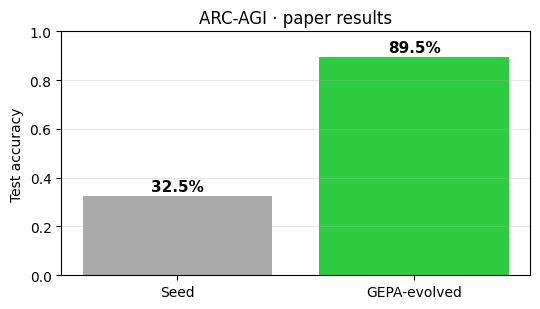

Cost: ~$0.14 / task with Gemini 3 Flash.
Caveat: artifacts/test_results.json reports 42.5% → 91.25% on an 80-puzzle dev subset
used during development; the headline numbers above are from the full eval split.


In [11]:
labels = ['Seed', 'GEPA-evolved']
values = [0.325, 0.895]   # paper, full eval split
fig, ax = plt.subplots(figsize=(5.5, 3.2))
bars = ax.bar(labels, values, color=['#AAAAAA', '#2ECC40'])
ax.set_ylim(0, 1.0); ax.set_ylabel('Test accuracy')
ax.set_title('ARC-AGI · paper results')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}',
            ha='center', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print('Cost: ~$0.14 / task with Gemini 3 Flash.')
print('Caveat: artifacts/test_results.json reports 42.5% → 91.25% on an 80-puzzle dev subset')
print('used during development; the headline numbers above are from the full eval split.')

**Side-by-side:**

| | Seed | GEPA-evolved |
|---|---|---|
| Lines of code | 12 | 170 |
| Approach | one-shot grid prediction | code synthesis + validate + fix + fallback |
| LLM calls / task | 1 | 2–4 |
| Cost / task | — | ~\$0.14 |
| Accuracy (paper, full eval split) | 32.5% | **89.5%** |
| Accuracy on running-example puzzle | 0% | 100% |

*The running-example puzzle was chosen as a clean illustrative case (one where the seed clearly fails and the evolved agent clearly succeeds). The full-split numbers above are the honest aggregate.*

## 10 · Run optimization yourself

Three ways to run `optimize_anything` against ARC, in increasing scope:

**(a) Tiny live demo — right here in the notebook.** Set `OPTIMIZE_LIVE = True` below, export `OPENROUTER_API_KEY`, re-run the cell. Optimizes `SEED_AGENT_CODE` against an 8-train / 8-val ARC slice (`artifacts/mini_dataset.json`) with a 30-metric-call budget. **~5 min, ~\$0.50.** Won't reproduce 89.5% — meant to show the loop closing in real time.

**(b) Full optimization** (multi-hour; paper reports total cost **\$144.70** = \$0.70 reflection + \$144 evaluation):

```bash
pip install gepa==0.1.1
git clone https://github.com/gepa-ai/gepa && cd gepa/examples/arc_agi
export OPENROUTER_API_KEY=sk-or-...
python main.py
```

**(c) Optimize a different artifact.** Swap `seed_candidate` for any text (a prompt, a config, a SQL template) and write an `evaluator(candidate, example) -> (score, SideInfo)` for your task. The reflection LM will read your `SideInfo` and propose mutations. That's the whole loop.

In [12]:
OPTIMIZE_LIVE = False   # set True + export OPENROUTER_API_KEY to actually run

if OPTIMIZE_LIVE:
    from gepa.optimize_anything import optimize_anything, GEPAConfig, EngineConfig, ReflectionConfig
    from arc_runtime import run_agent

    mini = json.loads((ARTIFACTS / 'mini_dataset.json').read_text())
    SEED_AGENT_CODE = EXAMPLE['seed']['agent_code']
    LM = 'openrouter/google/gemini-3-flash-preview'

    def evaluate(candidate, example):
        r = run_agent(candidate, example['train_in'], example['train_out'],
                      example['test_in'], example['test_out'], model_id=LM, max_llm_calls=10)
        score = r['training_score']
        side_info = {'problem_id': example['problem_id'],
                     'training_score': score, 'test_score': r['test_score'],
                     'error': r['error'], 'train_examples': r['train_examples']}
        return score, side_info

    BACKGROUND = ('You are optimizing a Python function `solve(train_in, train_out, test_in, llm)` that '
                  'must return {"train": [grids], "test": [[grid, grid], ...]} for ARC-AGI puzzles. '
                  'You may use up to 10 LLM calls per puzzle.')
    OBJECTIVE = 'Build an ARC-AGI agent that maximizes test_score.'

    result = optimize_anything(
        seed_candidate=SEED_AGENT_CODE,
        evaluator=evaluate,
        dataset=mini['trainset'], valset=mini['valset'],
        objective=OBJECTIVE, background=BACKGROUND,
        config=GEPAConfig(
            engine=EngineConfig(max_metric_calls=30, parallel=True, max_workers=4),
            reflection=ReflectionConfig(reflection_lm=LM),
        ),
    )
    best_score = max(result.val_aggregate_subscores) if result.val_aggregate_subscores else 0.0
    print(f'\nDone. Best validation score: {best_score:.1%}  (best_idx={result.best_idx})')
    print(f'Candidates explored: {result.num_candidates}  ·  metric calls: {result.total_metric_calls}')
else:
    print('OPTIMIZE_LIVE is False — set True + OPENROUTER_API_KEY to run a 5-min optimization.')
    print('See cell source above for the full call.')

OPTIMIZE_LIVE is False — set True + OPENROUTER_API_KEY to run a 5-min optimization.
See cell source above for the full call.
